In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.utils import resample
import warnings

warnings.filterwarnings('ignore')

In [2]:
# ==========================================
# 1. LOAD DATA & PREPROCESSING
# ==========================================
# Memuat dataset
# ============================================================
# 1. LOAD DATA: Membaca dataset final yang sudah di‑engineering
#    Sumber: hr_final_dataset.csv  yang ada pada Google Drive.
# ============================================================

file_id_gd = '1b0UXzrONSAKieqECNEw1BfE7O7nVwiMS'
file_name_gd = 'hr_final_dataset (2).csv'
# https://drive.google.com/file/d/1b0UXzrONSAKieqECNEw1BfE7O7nVwiMS/view?usp=sharing
!gdown --id {file_id_gd} --output "{file_name_gd}"
df = pd.read_csv(file_name_gd)

target_col = 'AttritionFlag'

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1b0UXzrONSAKieqECNEw1BfE7O7nVwiMS
To: /content/hr_final_dataset (2).csv
100% 2.36M/2.36M [00:00<00:00, 103MB/s]


In [3]:
# Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# 1. Train-Test Split (80:20)
# Menggunakan stratify agar proporsi target di train dan test sama
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scaling (Penting untuk KNN dan LogReg)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# ==========================================
# 2. MENANGANI IMBALANCE DATA (MANUAL UPSAMPLING/SMOTE)
# ==========================================
# Catatan: Kita melakukan resampling HANYA pada data latih untuk mencegah kebocoran data (data leakage)
train_data = pd.DataFrame(X_train_scaled, columns=X.columns)
train_data[target_col] = y_train.values

df_majority = train_data[train_data[target_col] == 0]
df_minority = train_data[train_data[target_col] == 1]

# Upsample kelas minoritas
df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

df_upsampled = pd.concat([df_majority, df_minority_upsampled])

X_train_resampled = df_upsampled.drop(target_col, axis=1).values
y_train_resampled = df_upsampled[target_col].values

In [5]:
# 3. BASELINE & MODEL COMPARISON
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else 0

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

results = []
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled) # Train pada data upsampled
    results.append(evaluate_model(model, X_test_scaled, y_test, name))

print("--- Hasil Perbandingan Model (Sebelum Tuning) ---")
print(pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False))

--- Hasil Perbandingan Model (Sebelum Tuning) ---
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
2        Random Forest  0.996599   1.000000  0.978873  0.989324  0.997640
4                  KNN  0.870748   0.558333  0.943662  0.701571  0.969990
1        Decision Tree  0.979592   0.949275  0.922535  0.935714  0.956538
3    Gradient Boosting  0.892290   0.631285  0.795775  0.704050  0.930120
0  Logistic Regression  0.780045   0.396825  0.704225  0.507614  0.819966


In [6]:
# 4. HYPERPARAMETER TUNING (Random Forest)
# ==========================================
# Kita tuning Random Forest karena performa awalnya sudah menjanjikan
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

print("\nSedang melakukan Tuning Hyperparameter...")
rf_random = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params,
                               n_iter=10, cv=3, scoring='roc_auc', random_state=42, n_jobs=-1)
rf_random.fit(X_train_resampled, y_train_resampled)

best_model = rf_random.best_estimator_
print(f"Best Parameters: {rf_random.best_params_}")

# Evaluasi Model Terbaik
final_res = evaluate_model(best_model, X_test_scaled, y_test, "Tuned Random Forest")
print("\n--- Performa Model Terbaik ---")
print(pd.DataFrame([final_res]))


Sedang melakukan Tuning Hyperparameter...
Best Parameters: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': True}

--- Performa Model Terbaik ---
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Tuned Random Forest  0.996599        1.0  0.978873  0.989324  0.998073


# 5. VISUALISASI HASIL

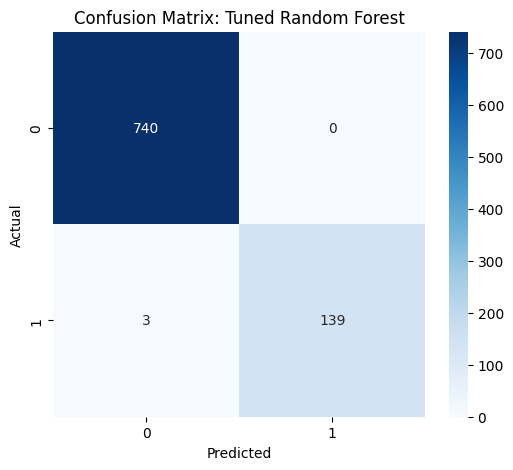

In [7]:
# A. Confusion Matrix
plt.figure(figsize=(6, 5))
y_pred_final = best_model.predict(X_test_scaled)
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Tuned Random Forest')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()

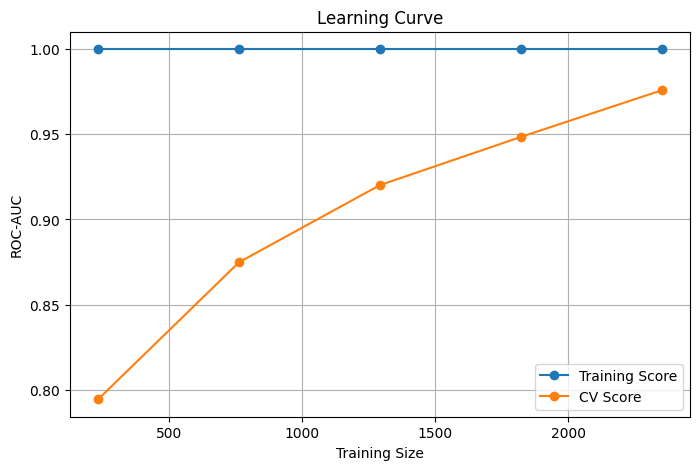

In [8]:
# B. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train_scaled, y_train, cv=3, scoring='roc_auc', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5))

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='CV Score')
plt.title('Learning Curve')
plt.xlabel('Training Size'); plt.ylabel('ROC-AUC')
plt.legend(); plt.grid()
plt.show()

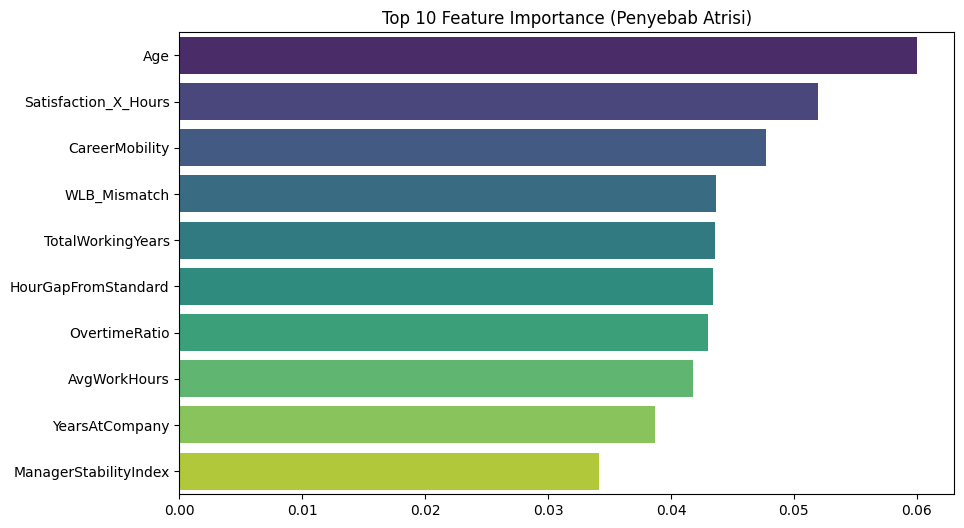

In [9]:
# C. Feature Importance
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1][:10] # Top 10
top_features = [X.columns[i] for i in indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=top_features, palette='viridis')
plt.title('Top 10 Feature Importance (Penyebab Atrisi)')
plt.show()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, fbeta_score
from sklearn.inspection import permutation_importance
from sklearn.utils import resample
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. PERSIAPAN DATA & MODEL ULANG
# ==========================================
# Load & Preprocessing (Sama seperti tahap sebelumnya untuk konsistensi)
df = pd.read_csv('hr_final_dataset (2).csv')
X = df.drop(columns=['AttritionFlag'])
y = df['AttritionFlag']

# Train-Test Split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Handling Imbalance (Upsampling Train Data Only)
train_df = pd.concat([X_train, y_train], axis=1)
df_maj = train_df[train_df.AttritionFlag == 0]
df_min = train_df[train_df.AttritionFlag == 1]
df_min_upsampled = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
train_upsampled = pd.concat([df_maj, df_min_upsampled])

X_train_final = train_upsampled.drop('AttritionFlag', axis=1)
y_train_final = train_upsampled['AttritionFlag']



In [11]:
# Melatih Model Terbaik (Random Forest Tuned)
best_rf = RandomForestClassifier(n_estimators=200, min_samples_split=2, min_samples_leaf=1, random_state=42)
best_rf.fit(X_train_final, y_train_final)

RandomForestClassifier(n_estimators=200, random_state=42)

In [12]:
# 2. EVALUASI GLOBAL
# ==========================================
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("--- GLOBAL PERFORMANCE ---")
print(pd.DataFrame([get_metrics(y_test, y_pred, y_prob)]))

--- GLOBAL PERFORMANCE ---
   Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  0.996599        1.0  0.978873  0.989324  0.998244


In [24]:
# 3. EVALUASI PER SEGMEN (FAIRNESS)
# ==========================================
print("\n--- SEGMENT PERFORMANCE (JobRole) ---")
segment_report = []

# Evaluasi berdasarkan JobRole
# Kita cari kolom yang mengandung 'JobRole' (karena One-Hot Encoding)
job_role_cols = [c for c in X.columns if 'JobRole' in c]

for col in job_role_cols:
    role_name = col.replace('JobRole_', '')
    # Filter data test yang memiliki role ini (nilai == 1)
    mask = X_test[col] == 1
    if mask.sum() > 0:
        y_sub_true = y_test[mask]
        y_sub_pred = y_pred[mask]
        y_sub_prob = y_prob[mask]

        # Hitung metric sederhana
        acc = accuracy_score(y_sub_true, y_sub_pred)

        # Initialize metrics as NaN, then compute if conditions are met
        prec = np.nan
        rec = np.nan
        f1 = np.nan
        f2 = np.nan
        roc_auc = np.nan

        # Check if there are positive samples in the subset for relevant metrics
        if y_sub_true.sum() > 0:
            rec = recall_score(y_sub_true, y_sub_pred)
            prec = precision_score(y_sub_true, y_sub_pred)
            f1 = f1_score(y_sub_true, y_sub_pred)
            f2 = fbeta_score(y_sub_true, y_sub_pred, beta=2)

        # ROC-AUC requires at least two unique classes
        if len(np.unique(y_sub_true)) > 1:
             roc_auc = roc_auc_score(y_sub_true, y_sub_prob)

        segment_report.append({
            'Segment': role_name,
            'Count': mask.sum(),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'F2-Score': f2,
            'ROC-AUC': roc_auc
        })

Segment_JobRole = pd.DataFrame(segment_report).sort_values('Recall')

Segment_JobRole


--- SEGMENT PERFORMANCE (JobRole) ---


,Segment,Count,Accuracy,Precision,Recall,F1-Score,F2-Score,ROC-AUC
7,Sales Executive,201,0.985075,1.0,0.88,0.93617,0.901639,0.988182
0,Healthcare Representative,80,1.000000,1.0,1.00,1.00000,1.000000,1.000000
2,Laboratory Technician,149,1.000000,1.0,1.00,1.00000,1.000000,1.000000
1,Human Resources,35,1.000000,1.0,1.00,1.00000,1.000000,1.000000
3,Manager,60,1.000000,1.0,1.00,1.00000,1.000000,1.000000
4,Manufacturing Director,92,1.000000,1.0,1.00,1.00000,1.000000,1.000000
5,Research Director,49,1.000000,1.0,1.00,1.00000,1.000000,1.000000
6,Research Scientist,166,1.000000,1.0,1.00,1.00000,1.000000,1.000000
8,Sales Representative,50,1.000000,1.0,1.00,1.00000,1.000000,1.000000


In [26]:
# 3. EVALUASI PER SEGMEN (FAIRNESS)
# ==========================================
print("\n--- SEGMENT PERFORMANCE (Gender) ---")
segment_report_gender = []

# Evaluasi berdasarkan Gender
# Kita cari kolom yang mengandung 'Gender' (karena One-Hot Encoding)
job_role_cols = [c for c in X.columns if 'Gender' in c]

for col in job_role_cols:
    role_name = col.replace('Gender_', '')
    # Filter data test yang memiliki role ini (nilai == 1)
    mask = X_test[col] == 1
    if mask.sum() > 0:
        y_sub_true = y_test[mask]
        y_sub_pred = y_pred[mask]
        y_sub_prob = y_prob[mask]

        # Hitung metric sederhana
        acc = accuracy_score(y_sub_true, y_sub_pred)

        # Initialize metrics as NaN, then compute if conditions are met
        prec = np.nan
        rec = np.nan
        f1 = np.nan
        f2 = np.nan
        roc_auc = np.nan

        # Check if there are positive samples in the subset for relevant metrics
        if y_sub_true.sum() > 0:
            rec = recall_score(y_sub_true, y_sub_pred)
            prec = precision_score(y_sub_true, y_sub_pred)
            f1 = f1_score(y_sub_true, y_sub_pred)
            f2 = fbeta_score(y_sub_true, y_sub_pred, beta=2)

        # ROC-AUC requires at least two unique classes
        if len(np.unique(y_sub_true)) > 1:
             roc_auc = roc_auc_score(y_sub_true, y_sub_prob)

        segment_report_gender.append({
            'Segment': role_name,
            'Count': mask.sum(),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'F2-Score': f2,
            'ROC-AUC': roc_auc
        })

Segment_Gender = pd.DataFrame(segment_report_gender).sort_values('Recall')

Segment_Gender


--- SEGMENT PERFORMANCE (Gender) ---


,Segment,Count,Accuracy,Precision,Recall,F1-Score,F2-Score,ROC-AUC
1,Male,526,0.994297,1.0,0.962963,0.981132,0.970149,0.996726
0,Female,356,1.000000,1.0,1.000000,1.000000,1.000000,1.000000


In [27]:
# 3. EVALUASI PER SEGMEN (FAIRNESS)
# ==========================================
print("\n--- SEGMENT PERFORMANCE (BusinessTravel) ---")
segment_report_businesstravel = []

# Evaluasi berdasarkan BusinessTravel
# Kita cari kolom yang mengandung 'BusinessTravel' (karena One-Hot Encoding)
job_role_cols = [c for c in X.columns if 'BusinessTravel' in c]

for col in job_role_cols:
    role_name = col.replace('BusinessTravel_', '')
    # Filter data test yang memiliki role ini (nilai == 1)
    mask = X_test[col] == 1
    if mask.sum() > 0:
        y_sub_true = y_test[mask]
        y_sub_pred = y_pred[mask]
        y_sub_prob = y_prob[mask]

        # Hitung metric sederhana
        acc = accuracy_score(y_sub_true, y_sub_pred)

        # Initialize metrics as NaN, then compute if conditions are met
        prec = np.nan
        rec = np.nan
        f1 = np.nan
        f2 = np.nan
        roc_auc = np.nan

        # Check if there are positive samples in the subset for relevant metrics
        if y_sub_true.sum() > 0:
            rec = recall_score(y_sub_true, y_sub_pred)
            prec = precision_score(y_sub_true, y_sub_pred)
            f1 = f1_score(y_sub_true, y_sub_pred)
            f2 = fbeta_score(y_sub_true, y_sub_pred, beta=2)

        # ROC-AUC requires at least two unique classes
        if len(np.unique(y_sub_true)) > 1:
             roc_auc = roc_auc_score(y_sub_true, y_sub_prob)

        segment_report_businesstravel.append({
            'Segment': role_name,
            'Count': mask.sum(),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'F2-Score': f2,
            'ROC-AUC': roc_auc
        })

Segment_BusinessTravel = pd.DataFrame(segment_report_businesstravel).sort_values('Recall')

Segment_BusinessTravel


--- SEGMENT PERFORMANCE (BusinessTravel) ---


,Segment,Count,Accuracy,Precision,Recall,F1-Score,F2-Score,ROC-AUC
2,Travel_Rarely,638,0.995298,1.0,0.969072,0.984293,0.975104,0.997504
0,Non-Travel,89,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
1,Travel_Frequently,155,1.000000,1.0,1.000000,1.000000,1.000000,1.000000


In [28]:
# 3. EVALUASI PER SEGMEN (FAIRNESS)
# ==========================================
print("\n--- SEGMENT PERFORMANCE (Department) ---")
segment_report_department = []

# Evaluasi berdasarkan Department
# Kita cari kolom yang mengandung 'Department' (karena One-Hot Encoding)
job_role_cols = [c for c in X.columns if 'Department' in c]

for col in job_role_cols:
    role_name = col.replace('Department_', '')
    # Filter data test yang memiliki role ini (nilai == 1)
    mask = X_test[col] == 1
    if mask.sum() > 0:
        y_sub_true = y_test[mask]
        y_sub_pred = y_pred[mask]
        y_sub_prob = y_prob[mask]

        # Hitung metric sederhana
        acc = accuracy_score(y_sub_true, y_sub_pred)

        # Initialize metrics as NaN, then compute if conditions are met
        prec = np.nan
        rec = np.nan
        f1 = np.nan
        f2 = np.nan
        roc_auc = np.nan

        # Check if there are positive samples in the subset for relevant metrics
        if y_sub_true.sum() > 0:
            rec = recall_score(y_sub_true, y_sub_pred)
            prec = precision_score(y_sub_true, y_sub_pred)
            f1 = f1_score(y_sub_true, y_sub_pred)
            f2 = fbeta_score(y_sub_true, y_sub_pred, beta=2)

        # ROC-AUC requires at least two unique classes
        if len(np.unique(y_sub_true)) > 1:
             roc_auc = roc_auc_score(y_sub_true, y_sub_prob)

        segment_report_department.append({
            'Segment': role_name,
            'Count': mask.sum(),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'F2-Score': f2,
            'ROC-AUC': roc_auc
        })

Segment_Department = pd.DataFrame(segment_report_department).sort_values('Recall')

Segment_Department


--- SEGMENT PERFORMANCE (Department) ---


,Segment,Count,Accuracy,Precision,Recall,F1-Score,F2-Score,ROC-AUC
1,Research & Development,562,0.994662,1.0,0.963855,0.981595,0.970874,0.997019
0,Human Resources,28,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
2,Sales,292,1.000000,1.0,1.000000,1.000000,1.000000,1.000000


In [33]:
# 3. EVALUASI PER SEGMEN (FAIRNESS)
# ==========================================
print("\n--- SEGMENT PERFORMANCE (EducationField) ---")
segment_report_education = []

# Evaluasi berdasarkan EducationField
# Kita cari kolom yang mengandung 'EducationField' (karena One-Hot Encoding)
job_role_cols = [c for c in X.columns if 'EducationField' in c]

for col in job_role_cols:
    role_name = col.replace('EducationField_', '')
    # Filter data test yang memiliki role ini (nilai == 1)
    mask = X_test[col] == 1
    if mask.sum() > 0:
        y_sub_true = y_test[mask]
        y_sub_pred = y_pred[mask]
        y_sub_prob = y_prob[mask]

        # Hitung metric sederhana
        acc = accuracy_score(y_sub_true, y_sub_pred)

        # Initialize metrics as NaN, then compute if conditions are met
        prec = np.nan
        rec = np.nan
        f1 = np.nan
        f2 = np.nan
        roc_auc = np.nan

        # Check if there are positive samples in the subset for relevant metrics
        if y_sub_true.sum() > 0:
            rec = recall_score(y_sub_true, y_sub_pred)
            prec = precision_score(y_sub_true, y_sub_pred)
            f1 = f1_score(y_sub_true, y_sub_pred)
            f2 = fbeta_score(y_sub_true, y_sub_pred, beta=2)

        # ROC-AUC requires at least two unique classes
        if len(np.unique(y_sub_true)) > 1:
             roc_auc = roc_auc_score(y_sub_true, y_sub_prob)

        segment_report_education.append({
            'Segment': role_name,
            'Count': mask.sum(),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'F2-Score': f2,
            'ROC-AUC': roc_auc
        })

Segment_EducationField = pd.DataFrame(segment_report_education).sort_values('Recall')

Segment_EducationField


--- SEGMENT PERFORMANCE (EducationField) ---


,Segment,Count,Accuracy,Precision,Recall,F1-Score,F2-Score,ROC-AUC
3,Medical,267,0.988764,1.0,0.938776,0.968421,0.950413,0.994289
0,Human Resources,10,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
1,Life Sciences,383,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
2,Marketing,109,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
5,Technical Degree,68,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
4,Other,45,1.000000,NaN,NaN,NaN,NaN,NaN


In [34]:
# 3. EVALUASI PER SEGMEN (FAIRNESS)
# ==========================================
print("\n--- SEGMENT PERFORMANCE (TenureBucket) ---")
segment_report_tenure = []

# Evaluasi berdasarkan TenureBucket
# Kita cari kolom yang mengandung 'TenureBucket' (karena One-Hot Encoding)
job_role_cols = [c for c in X.columns if 'TenureBucket' in c]

for col in job_role_cols:
    role_name = col.replace('TenureBucket_', '')
    # Filter data test yang memiliki role ini (nilai == 1)
    mask = X_test[col] == 1
    if mask.sum() > 0:
        y_sub_true = y_test[mask]
        y_sub_pred = y_pred[mask]
        y_sub_prob = y_prob[mask]

        # Hitung metric sederhana
        acc = accuracy_score(y_sub_true, y_sub_pred)

        # Initialize metrics as NaN, then compute if conditions are met
        prec = np.nan
        rec = np.nan
        f1 = np.nan
        f2 = np.nan
        roc_auc = np.nan

        # Check if there are positive samples in the subset for relevant metrics
        if y_sub_true.sum() > 0:
            rec = recall_score(y_sub_true, y_sub_pred)
            prec = precision_score(y_sub_true, y_sub_pred)
            f1 = f1_score(y_sub_true, y_sub_pred)
            f2 = fbeta_score(y_sub_true, y_sub_pred, beta=2)

        # ROC-AUC requires at least two unique classes
        if len(np.unique(y_sub_true)) > 1:
             roc_auc = roc_auc_score(y_sub_true, y_sub_prob)

        segment_report_tenure.append({
            'Segment': role_name,
            'Count': mask.sum(),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'F2-Score': f2,
            'ROC-AUC': roc_auc
        })

Segment_TenureBucket = pd.DataFrame(segment_report_tenure).sort_values('Recall')

Segment_TenureBucket


--- SEGMENT PERFORMANCE (TenureBucket) ---


,Segment,Count,Accuracy,Precision,Recall,F1-Score,F2-Score,ROC-AUC
3,5-10,319,0.990596,1.0,0.928571,0.962963,0.942029,0.995702
0,0-1,25,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
1,1-3,174,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
2,3-5,135,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
4,>10,229,1.000000,1.0,1.000000,1.000000,1.000000,1.000000



Calculating Feature Importance...


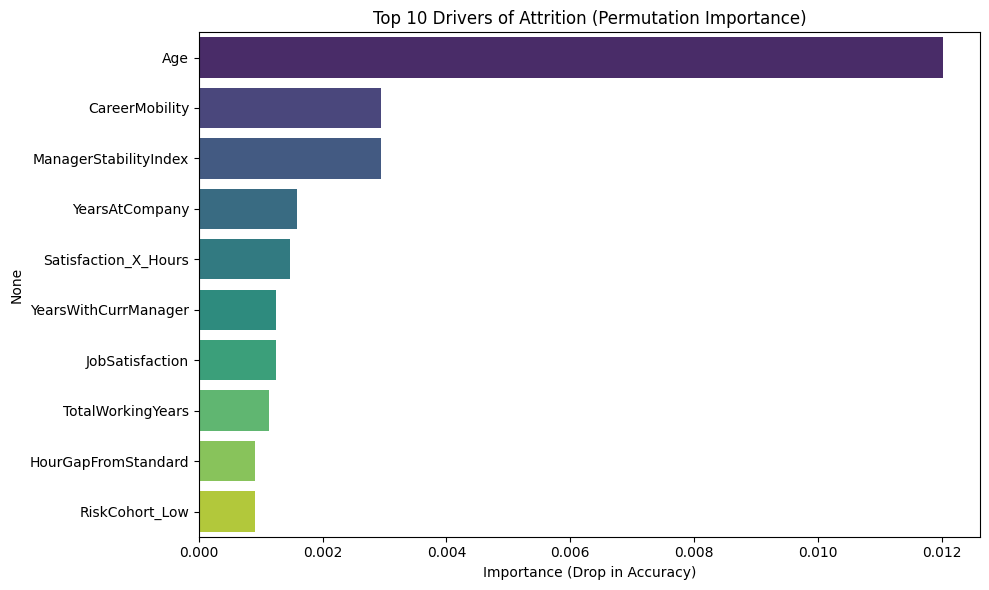

In [14]:
# 4. INTERPRETABILITY (Permutation Importance)
# ==========================================
# Alternatif SHAP yang robust: Permutation Importance
print("\nCalculating Feature Importance...")
perm_importance = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

sorted_idx = perm_importance.importances_mean.argsort()[::-1][:10]
plt.figure(figsize=(10, 6))
sns.barplot(x=perm_importance.importances_mean[sorted_idx], y=X.columns[sorted_idx], palette='viridis')
plt.title('Top 10 Drivers of Attrition (Permutation Importance)')
plt.xlabel('Importance (Drop in Accuracy)')
plt.tight_layout()
plt.show()


Generating SHAP Plots...


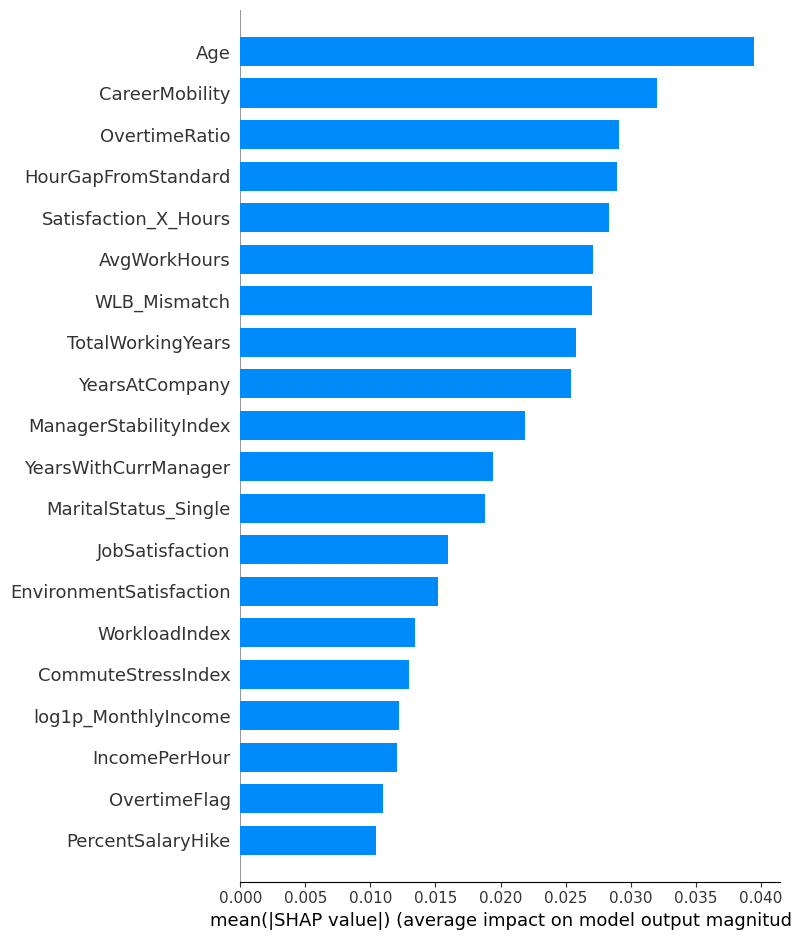

In [18]:
# 5. SHAP VISUALIZATION
# ==========================================
try:
    import shap
    print("\nGenerating SHAP Plots...")
    explainer = shap.TreeExplainer(best_rf)
    # Hitung nilai SHAP menggunakan representasi array numpy dari X_test.
    shap_values = explainer.shap_values(X_test.values)

    # Summary Plot
    plt.figure()
    # Teruskan (masukkan) representasi array numpy dari X_test dan berikan nama fitur secara eksplisit
    # Akses nilai SHAP untuk kelas 1 secara benar dari array 3D tersebut
    shap.summary_plot(shap_values[:, :, 1], X_test.values, feature_names=X_test.columns.tolist(), plot_type="bar") # Class 1 (Attrition)
    plt.show()

    # Force Plot untuk 1 sample (Interactive JS, sulit di static image, kita gunakan matplotlib jika bisa)
    # shap.force_plot(explainer.expected_value[1], shap_values[1][0,:], X_test.iloc[0,:], matplotlib=True)

except ImportError:
    print("\n[INFO] Library SHAP tidak terdeteksi. Gunakan Permutation Importance di atas sebagai alternatif valid.")
except Exception as e:
    print(f"\n[ERROR] SHAP plotting failed: {e}")
    print("This error often occurs due to subtle mismatches in feature handling,\
    especially when mixing pandas DataFrames and numpy arrays without explicit feature names.")
    print("The code has been updated to use numpy arrays for SHAP value calculation\
    and plotting, and feature names are now explicitly provided.")


Generating SHAP Plots...


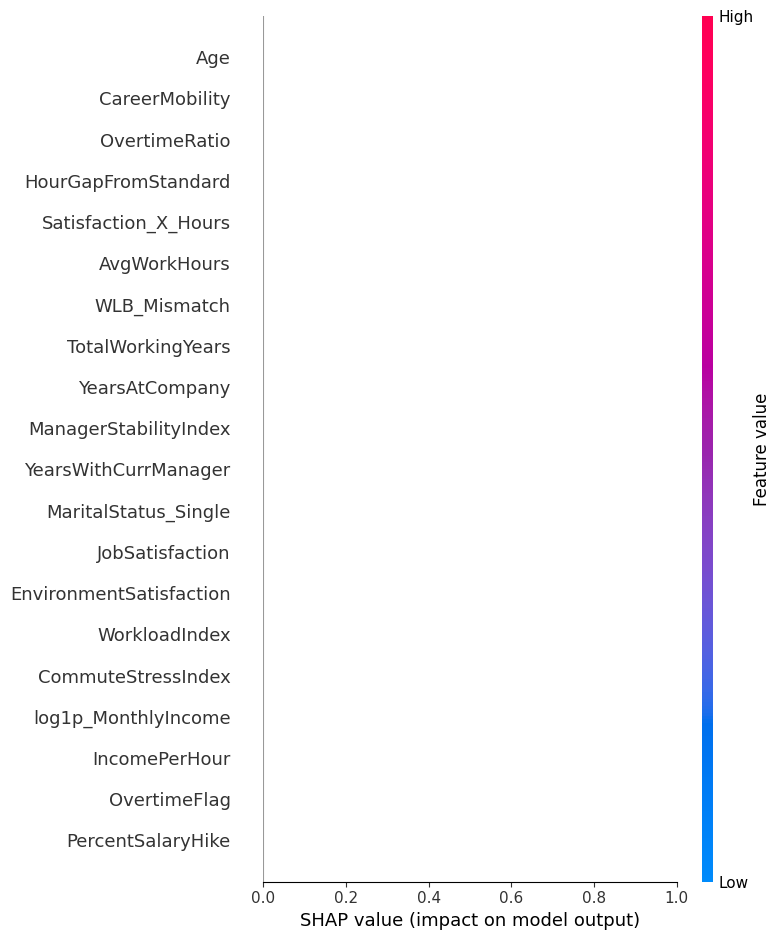

In [30]:
# 5. SHAP VISUALIZATION
# ==========================================
try:
    import shap
    print("\nGenerating SHAP Plots...")
    explainer = shap.TreeExplainer(best_rf)
    # Hitung nilai SHAP menggunakan representasi array numpy dari X_test.
    shap_values = explainer.shap_values(X_test.values)

    # Summary Plot
    plt.figure()
    # Teruskan (masukkan) representasi array numpy dari X_test dan berikan nama fitur secara eksplisit
    # Akses nilai SHAP untuk kelas 1 secara benar dari array 3D tersebut
    shap.summary_plot(shap_values[:, :, 1], X_test.values, feature_names=X_test.columns.tolist(), plot_type="beeswarm") # Class 1 (Attrition)
    plt.show()

    # Force Plot untuk 1 sample (Interactive JS, sulit di static image, kita gunakan matplotlib jika bisa)
    # shap.force_plot(explainer.expected_value[1], shap_values[1][0,:], X_test.iloc[0,:], matplotlib=True)

except ImportError:
    print("\n[INFO] Library SHAP tidak terdeteksi. Gunakan Permutation Importance di atas sebagai alternatif valid.")
except Exception as e:
    print(f"\n[ERROR] SHAP plotting failed: {e}")
    print("This error often occurs due to subtle mismatches in feature handling,\
    especially when mixing pandas DataFrames and numpy arrays without explicit feature names.")
    print("The code has been updated to use numpy arrays for SHAP value calculation\
    and plotting, and feature names are now explicitly provided.")


Generating SHAP Beeswarm Plot for One-Hot Encoded Columns...


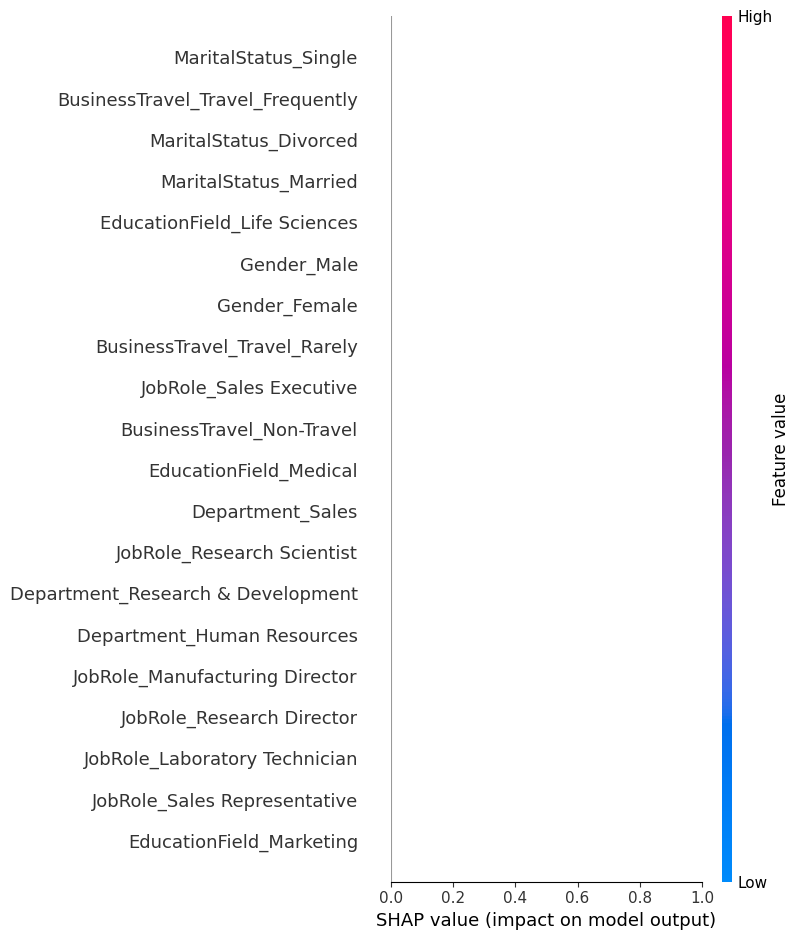

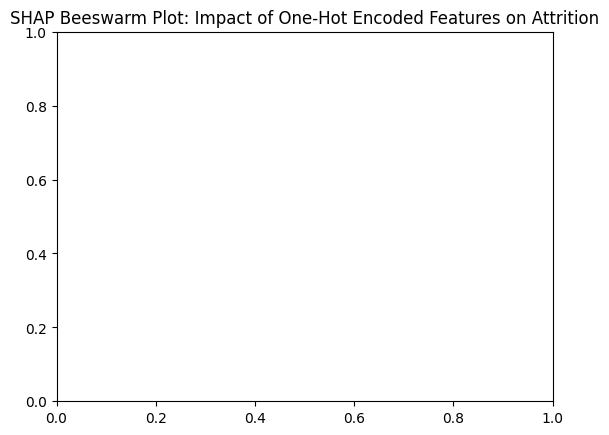

In [31]:
# 5. SHAP VISUALIZATION (Beeswarm Plot for One-Hot Encoded Columns)
# ==========================================
try:
    import shap
    print("\nGenerating SHAP Beeswarm Plot for One-Hot Encoded Columns...")

    # Identify one-hot encoded columns based on common prefixes
    ohe_prefixes = ['BusinessTravel_', 'Department_', 'EducationField_', 'Gender_', 'JobRole_', 'MaritalStatus_', 'OverTime_']
    ohe_columns = [col for col in X_test.columns if any(col.startswith(prefix) for prefix in ohe_prefixes)]

    if not ohe_columns:
        print("No One-Hot Encoded columns found with common prefixes. Skipping OHE SHAP plot.")
    else:
        # Filter X_test and get indices for these columns
        X_test_ohe = X_test[ohe_columns]
        ohe_indices = [X_test.columns.get_loc(col) for col in ohe_columns]

        # Filter shap_values to correspond to these OHE columns
        # Ensure we are indexing the correct dimension for features (the second dimension in shap_values[:, :, 1])
        shap_values_ohe = shap_values[:, ohe_indices, 1] # Select class 1 and specific columns

        # Summary Plot for OHE columns
        plt.figure(figsize=(12, 8)) # Adjust figure size for better readability
        shap.summary_plot(shap_values_ohe, X_test_ohe.values, feature_names=X_test_ohe.columns.tolist(), plot_type="beeswarm")
        plt.title('SHAP Beeswarm Plot: Impact of One-Hot Encoded Features on Attrition')
        plt.show()

except ImportError:
    print("\n[INFO] Library SHAP tidak terdeteksi. Gunakan Permutation Importance di atas sebagai alternatif valid.")
except Exception as e:
    print(f"\n[ERROR] SHAP plotting failed for OHE columns: {e}")
    print("This error often occurs due to subtle mismatches in feature handling,\
    especially when mixing pandas DataFrames and numpy arrays without explicit feature names.")
    print("The code has been updated to use numpy arrays for SHAP value calculation\
    and plotting, and feature names are now explicitly provided.")